OBJECTIVE OF THIS MODULE

We will build:

→ LightGBM Energy Consumption Prediction System

Target variable:

units

The model will learn:

enterprise consumption behavior
operational efficiency
regional energy patterns
service utilization impact

STEP 1 — Import Libraries

In [2]:
# ======================================
# IMPORT LIBRARIES
# ======================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — Load Final Dataset

In [3]:
# ======================================
# LOAD FINAL DATASET
# ======================================

df = pd.read_csv("../data/final_energy_dataset.csv")

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency,efficiency_category
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938,HIGH EFFICIENCY
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578,MEDIUM EFFICIENCY
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432,HIGH EFFICIENCY
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751,HIGH EFFICIENCY
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000,MEDIUM EFFICIENCY


STEP 3 — Select Important Features

In [4]:
# ======================================
# FEATURE SELECTION
# ======================================

selected_features = [
    'circle',
    'division',
    'subdivision',
    'section',
    'area',
    'totservices',
    'billdservices',
    'load',
    'units_per_service',
    'service_utilization_ratio',
    'avg_load_per_service',
    'load_efficiency'
]

target = 'units'

print("Selected Features:")
print(selected_features)

Selected Features:
['circle', 'division', 'subdivision', 'section', 'area', 'totservices', 'billdservices', 'load', 'units_per_service', 'service_utilization_ratio', 'avg_load_per_service', 'load_efficiency']


STEP 4 — Create Model Dataset

In [5]:
# ======================================
# CREATE MODEL DATASET
# ======================================

model_df = df[selected_features + [target]].copy()

display(model_df.head())

,circle,division,subdivision,section,area,totservices,billdservices,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency,units
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,24,22.0,30.44,138.916667,0.916667,1.268333,109.526938,3334
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),77,76.0,117.27,122.636364,0.987013,1.522987,80.523578,9443
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,24,23.0,29.74,135.083333,0.958333,1.239167,109.011432,3242
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,105,101.0,144.92,160.600000,0.961905,1.380190,116.360751,16863
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,101,99.0,101.00,67.000000,0.980198,1.000000,67.000000,6767


STEP 5 — Encode Categorical Columns

In [6]:
# ======================================
# LABEL ENCODING
# ======================================

categorical_columns = [
    'circle',
    'division',
    'subdivision',
    'section',
    'area'
]

label_encoders = {}

for col in categorical_columns:
    
    le = LabelEncoder()
    
    model_df[col] = le.fit_transform(
        model_df[col].astype(str)
    )
    
    label_encoders[col] = le

print("Categorical encoding completed.")

Categorical encoding completed.


STEP 6 — Split Features & Target

In [7]:
# ======================================
# SPLIT FEATURES & TARGET
# ======================================

X = model_df[selected_features]

y = model_df[target]

print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Matrix Shape: (15904, 12)
Target Shape: (15904,)


STEP 7 — Train/Test Split

In [8]:
# ======================================
# TRAIN TEST SPLIT
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (12723, 12)
Testing Shape: (3181, 12)


STEP 8 — Train LightGBM Model

In [9]:
# ======================================
# LIGHTGBM MODEL TRAINING
# ======================================

model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

print("LightGBM Model Trained Successfully.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2490
[LightGBM] [Info] Number of data points in the train set: 12723, number of used features: 12
[LightGBM] [Info] Start training from score 23625.076790
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

STEP 9 — Generate Predictions

In [10]:
# ======================================
# PREDICTIONS
# ======================================

y_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


STEP 10 — Model Evaluation

RMSE
RMSE=n1	​∑i=1n​(yi​−y^​i​)2	​

MAE
MAE=n1​∑i=1n​∣yi​−y^​i​∣

In [11]:
# ======================================
# MODEL EVALUATION
# ======================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("===== MODEL PERFORMANCE =====")

print(f"MAE : {mae:.2f}")

print(f"RMSE: {rmse:.2f}")

print(f"R² Score: {r2:.4f}")

===== MODEL PERFORMANCE =====
MAE : 1406.81
RMSE: 14840.88
R² Score: 0.9549


STEP 11 — Actual vs Predicted Plot

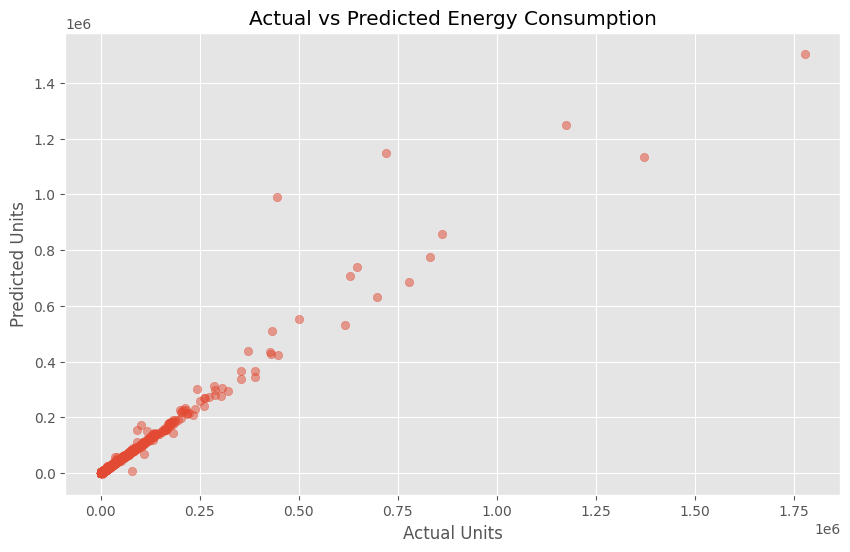

In [12]:
# ======================================
# ACTUAL VS PREDICTED
# ======================================

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Units")

plt.ylabel("Predicted Units")

plt.title("Actual vs Predicted Energy Consumption")

plt.show()

STEP 12 — Feature Importance

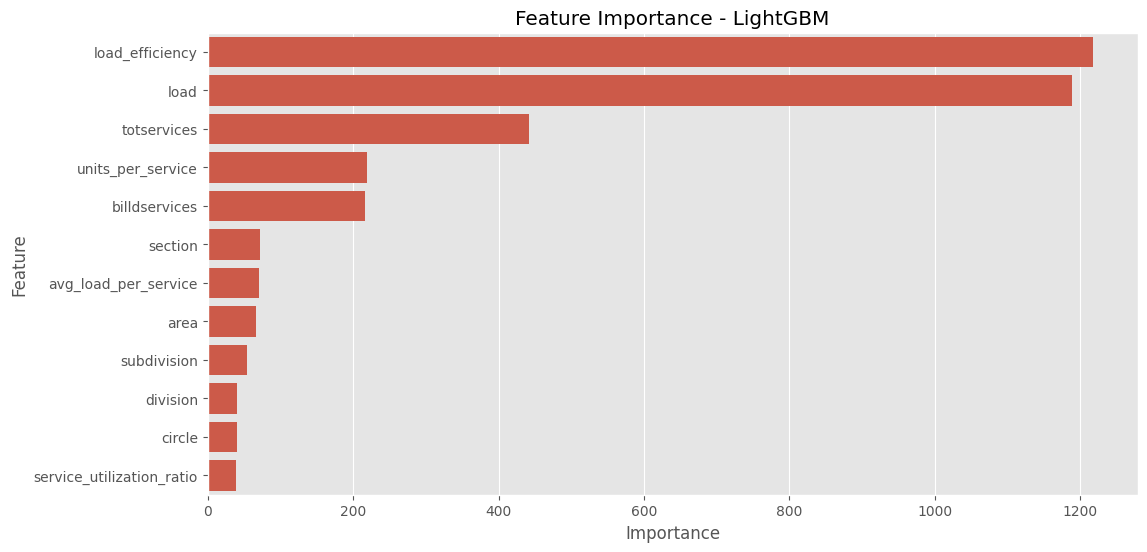

,Feature,Importance
11,load_efficiency,1218
7,load,1189
5,totservices,442
8,units_per_service,219
6,billdservices,217
3,section,72
10,avg_load_per_service,70
4,area,66
2,subdivision,54
1,division,40


In [13]:
# ======================================
# FEATURE IMPORTANCE
# ======================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - LightGBM")

plt.show()

display(feature_importance)

STEP 13 — Save Trained Model

In [14]:
# ======================================
# SAVE MODEL
# ======================================

import joblib

joblib.dump(
    model,
    "../models/lightgbm_energy_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
